In [10]:
import xarray as xr

from fastjmd95 import rho
import numpy as np
import matplotlib.pyplot as plt
from xgcm import Grid


In [11]:
ds = xr.open_dataset('TS_timestep2736.nc')



In [4]:
pd0 = rho(ds.Salt, ds.Theta, 0.)








In [20]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (k: 51, j: 100, i: 100, i_g: 100, j_g: 100)
Coordinates:
  * i        (i) int16 200B 50 51 52 53 54 55 56 ... 143 144 145 146 147 148 149
  * j_g      (j_g) int16 200B 3980 3981 3982 3983 3984 ... 4076 4077 4078 4079
  * j        (j) int16 200B 3980 3981 3982 3983 3984 ... 4076 4077 4078 4079
  * i_g      (i_g) int16 200B 50 51 52 53 54 55 56 ... 144 145 146 147 148 149
    time     datetime64[ns] 8B ...
    face     int16 2B ...
  * k        (k) int16 102B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
Data variables:
    Theta    (k, j, i) float32 2MB ...
    Salt     (k, j, i) float32 2MB ...
    U        (k, j, i_g) float32 2MB ...
    V        (k, j_g, i) float32 2MB ...
    Z        (k) float32 204B ...
    XC       (j, i) float32 40kB ...
    YC       (j, i) float32 40kB ...

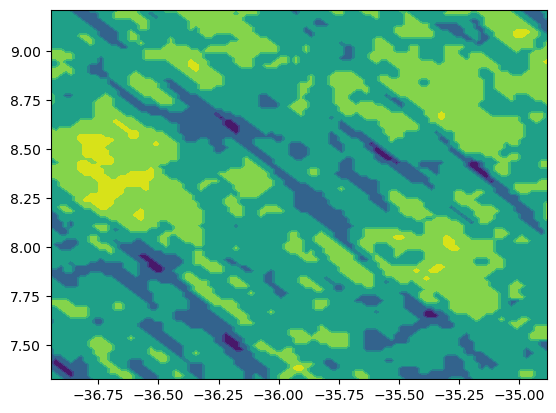

In [31]:
mlk = pd0.diff('k').argmax('k')
mld = ds.Z[mlk]
plt.contourf(ds.XC,ds.YC,mld)

In [5]:
i_extent = slice(50,150)
j_extent = slice(3980,4080)
slice1=np.zeros((51,100))
slice2=np.zeros((51,100))
x1=np.zeros((100))
y1=np.zeros((100))
for i in range(0,100):
    slice1[:,i] = ds.Theta[:,i,i].values
    slice2[:,i] = ds.Salt[:,i,i].values
    x1[i] = ds.XC[i,i].values
    y1[i] = ds.YC[i,i].values

In [6]:

pd0 = rho(slice2, slice1, 0.)

In [13]:
pd0.shape

(51, 100)

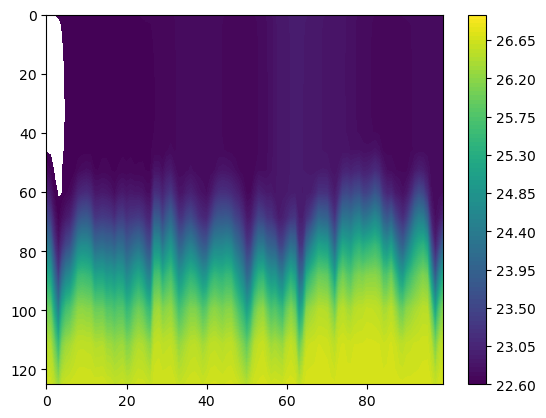

In [18]:
cs = plt.contourf(np.arange(0,100), -ds.Z.values[0:24], pd0[0:24,:]-1000,levels=np.arange(22.6,27,0.05))
plt.ylim(125,0)
plt.colorbar(cs)